# ML (Regression)
- Baselines: Linear Regression, Ridge Regression
- Non-linear model: kNN Regression (uniform vs distance)
- Hyperparameter tuning with 5-fold CV
- Key plots for reporting

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Helper
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

## 1) Loading data

In [ ]:
BASE_DIR = "/Users/ipekgezer"
DATA_FILE = "country_year_women_ratio_vdem_multi.csv"

local_path = os.path.join(BASE_DIR, DATA_FILE)
fallback_path = "/mnt/data/country_year_women_ratio_vdem_multi.csv"

DATA_PATH = local_path if os.path.exists(local_path) else fallback_path
print("Using DATA_PATH:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Using DATA_PATH: /Users/ipekgezer/country_year_women_ratio_vdem_multi.csv
Shape: (1359, 18)


,country,year,n_news,n_images_people,male_total,female_total,people_total,female_ratio,v2x_polyarchy,v2x_polyarchy_vdem,v2x_libdem,v2x_egaldem,v2fsuffrage,v2exfemhos,v2exfemhog,v2lgqugen,v2lgfemleg,v2x_civlib
0,AGO,2022,304,304,1638,445,2083,0.213634,0.327,0.327,0.154,0.132,100.0,0.0,NaN,1.0,33.64,0.602
1,AGO,2023,300,300,1531,356,1887,0.188659,0.330,0.330,0.157,0.140,100.0,0.0,NaN,1.0,33.64,0.598
2,AGO,2024,269,269,1422,309,1731,0.178510,0.340,0.340,0.164,0.138,100.0,0.0,NaN,1.0,39.60,0.624
3,ALB,2017,11,11,65,15,80,0.187500,0.537,0.537,0.440,0.384,100.0,0.0,0.0,2.0,27.86,0.889
4,ALB,2022,1,2,4,0,4,0.000000,0.520,0.520,0.433,0.390,100.0,0.0,0.0,2.0,35.70,0.886


In [ ]:
#quick checks + year filter
print("Year range:", df["year"].min(), "-", df["year"].max())
print("Missing female_ratio:", int(df["female_ratio"].isna().sum()))

YEAR_MIN = 2000
df_model = df[df["year"] >= YEAR_MIN].copy()
print("After year >= ", YEAR_MIN, "shape:", df_model.shape)


Year range: 1950 - 2024
Missing female_ratio: 0
After year >=  2000 shape: (1355, 18)


## 2) Preparing modeling table

In [ ]:
# Feature set
feature_cols = [
    "v2x_polyarchy",
    "v2x_libdem",
    "v2x_egaldem",
    "v2x_civlib",
    "v2fsuffrage",
    "v2lgqugen",
    "v2lgfemleg"
]

# Build df_ml (droping rows with missing target)
df_ml = df_model[["country", "year", "female_ratio"] + feature_cols].copy()
df_ml = df_ml.dropna(subset=["female_ratio"]).reset_index(drop=True)

print("df_ml shape:", df_ml.shape)
df_ml.head()


df_ml shape: (1355, 10)


,country,year,female_ratio,v2x_polyarchy,v2x_libdem,v2x_egaldem,v2x_civlib,v2fsuffrage,v2lgqugen,v2lgfemleg
0,AGO,2022,0.213634,0.327,0.154,0.132,0.602,100.0,1.0,33.64
1,AGO,2023,0.188659,0.330,0.157,0.140,0.598,100.0,1.0,33.64
2,AGO,2024,0.178510,0.340,0.164,0.138,0.624,100.0,1.0,39.60
3,ALB,2017,0.187500,0.537,0.440,0.384,0.889,100.0,2.0,27.86
4,ALB,2022,0.000000,0.520,0.433,0.390,0.886,100.0,2.0,35.70


In [ ]:
# Train/test split
X = df_ml[feature_cols]
y = df_ml["female_ratio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (1084, 7) Test: (271, 7)


## 3) Baselines: Linear Regression and Ridge Regression

In [ ]:
def eval_regression(pipe, name):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    out = {
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": rmse(y_test, pred),
        "R2": r2_score(y_test, pred),
        "pred": pred
    }
    return out

# Linear
lin_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# RidgeCV
alphas = np.logspace(-4, 4, 50)
ridge_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=alphas, cv=5))
])

lin_res = eval_regression(lin_pipe, "Linear")
ridge_res = eval_regression(ridge_pipe, "RidgeCV")

# Extract best alpha robustly
ridge_model = ridge_pipe.named_steps["model"]
best_alpha = getattr(ridge_model, "alpha_", None)
if best_alpha is None:
    best_alpha = getattr(ridge_model, "alpha", None)
ridge_res["model"] = f"RidgeCV (alpha={best_alpha})"

pd.DataFrame([
    {k: lin_res[k] for k in ["model","MAE","RMSE","R2"]},
    {k: ridge_res[k] for k in ["model","MAE","RMSE","R2"]},
])


,model,MAE,RMSE,R2
0,Linear,0.062419,0.087591,0.160492
1,RidgeCV (alpha=3.727593720314938),0.062813,0.087854,0.155452


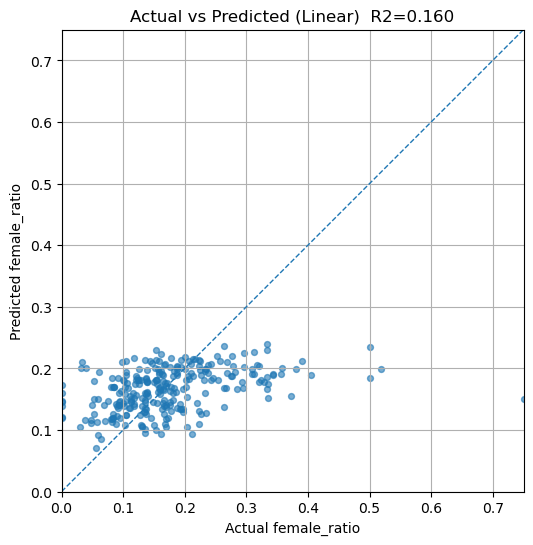

In [ ]:
# Actual vs Predicted (Linear)
y_true = y_test.to_numpy()
y_hat = lin_res["pred"]

mn = float(min(y_true.min(), y_hat.min()))
mx = float(max(y_true.max(), y_hat.max()))

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_hat, s=18, alpha=0.6)
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1)
plt.xlim(mn, mx); plt.ylim(mn, mx)
plt.gca().set_aspect("equal", adjustable="box")
plt.title(f"Actual vs Predicted (Linear)  R2={lin_res['R2']:.3f}")
plt.xlabel("Actual female_ratio")
plt.ylabel("Predicted female_ratio")
plt.grid(True)
plt.show()


In [ ]:
# Ridge coefficients
coef = ridge_pipe.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": feature_cols, "coef": coef}).sort_values("coef", ascending=False)
coef_df


,feature,coef
1,v2x_libdem,0.053678
6,v2lgfemleg,0.022804
0,v2x_polyarchy,0.012296
3,v2x_civlib,0.010904
4,v2fsuffrage,-0.001745
5,v2lgqugen,-0.004234
2,v2x_egaldem,-0.057700


## 4) kNN Regression:

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
k_list = [1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 51]

def tune_knn(weights_mode):
    mean_rmse, std_rmse = [], []
    for k in k_list:
        pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("knn", KNeighborsRegressor(n_neighbors=k, weights=weights_mode))
        ])
        neg_mse = cross_val_score(pipe, X, y, cv=cv, scoring="neg_mean_squared_error")
        rmse_scores = np.sqrt(-neg_mse)
        mean_rmse.append(rmse_scores.mean())
        std_rmse.append(rmse_scores.std())
    best_idx = int(np.argmin(mean_rmse))
    return {
        "mode": weights_mode,
        "best_k": k_list[best_idx],
        "CV_RMSE_mean": mean_rmse[best_idx],
        "CV_RMSE_std": std_rmse[best_idx],
        "curve_mean": mean_rmse,
        "curve_std": std_rmse
    }

def fit_eval_knn(best_k, weights_mode):
    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=best_k, weights=weights_mode))
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return {
        "model": f"kNN ({weights_mode}), k={best_k}",
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": rmse(y_test, pred),
        "R2": r2_score(y_test, pred),
        "pipe": pipe,
        "pred": pred
    }

t_uni = tune_knn("uniform")
t_dist = tune_knn("distance")

knn_uni = fit_eval_knn(t_uni["best_k"], "uniform")
knn_dist = fit_eval_knn(t_dist["best_k"], "distance")

results = pd.DataFrame([
    {k: lin_res[k] for k in ["model","MAE","RMSE","R2"]},
    {k: ridge_res[k] for k in ["model","MAE","RMSE","R2"]},
    {k: knn_uni[k] for k in ["model","MAE","RMSE","R2"]},
    {k: knn_dist[k] for k in ["model","MAE","RMSE","R2"]},
]).sort_values("RMSE")
results


,model,MAE,RMSE,R2
3,"kNN (distance), k=9",0.050165,0.080509,0.290761
2,"kNN (uniform), k=7",0.055513,0.083938,0.229053
0,Linear,0.062419,0.087591,0.160492
1,RidgeCV (alpha=3.727593720314938),0.062813,0.087854,0.155452


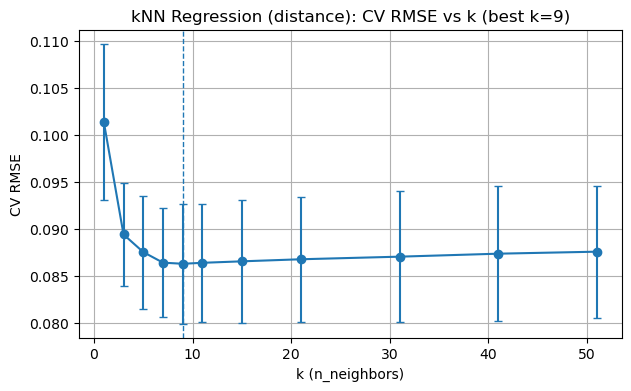

Best k: 9
Best CV RMSE: 0.08631961896982407 +/- 0.0063602129996843506


In [ ]:
# k tuning curve for distance-weighted kNN (with error bars)
mean_rmse = t_dist["curve_mean"]
std_rmse  = t_dist["curve_std"]
best_k = t_dist["best_k"]

plt.figure(figsize=(7,4))
plt.errorbar(k_list, mean_rmse, yerr=std_rmse, marker="o", capsize=3)
plt.axvline(best_k, linestyle="--", linewidth=1)
plt.title(f"kNN Regression (distance): CV RMSE vs k (best k={best_k})")
plt.xlabel("k (n_neighbors)")
plt.ylabel("CV RMSE")
plt.grid(True)
plt.show()

print("Best k:", best_k)
print("Best CV RMSE:", mean_rmse[k_list.index(best_k)], "+/-", std_rmse[k_list.index(best_k)])


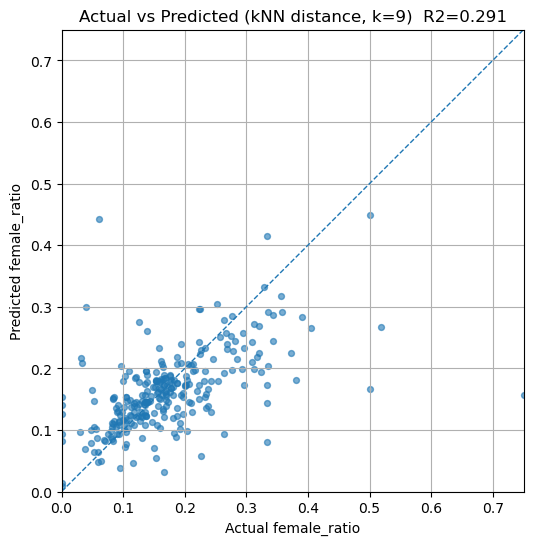

In [ ]:
# Actual vs Predicted for best kNN (distance)
y_true = y_test.to_numpy()
y_hat = knn_dist["pred"]

mn = float(min(y_true.min(), y_hat.min()))
mx = float(max(y_true.max(), y_hat.max()))

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_hat, s=18, alpha=0.6)
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1)
plt.xlim(mn, mx); plt.ylim(mn, mx)
plt.gca().set_aspect("equal", adjustable="box")
plt.title(f"Actual vs Predicted (kNN distance, k={t_dist['best_k']})  R2={knn_dist['R2']:.3f}")
plt.xlabel("Actual female_ratio")
plt.ylabel("Predicted female_ratio")
plt.grid(True)
plt.show()
